# **APE003: Grupo I**

### **Teoría de la Distribución y Probabilidad**

### Kiara Salomé Condoy Morocho

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import randint, norm, binom, uniform
import seaborn as sns

# Configuracion de estilo
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

print("Entorno configurado correctamente")


Entorno configurado correctamente


In [2]:
# Variable aleatoria: resultado de un dado
# X puede tomar valores: 1, 2, 3, 4, 5, 6

# Valores posibles
x_valores = np.array([1, 2, 3, 4, 5, 6])

# PMF: cada valor tiene probabilidad 1/6
pmf_dado = np.array([1/6, 1/6, 1/6, 1/6, 1/6, 1/6])

print("Valores de X:", x_valores)
print("PMF p(x):", pmf_dado)
print("Suma de probabilidades:", np.sum(pmf_dado))


Valores de X: [1 2 3 4 5 6]
PMF p(x): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Suma de probabilidades: 0.9999999999999999


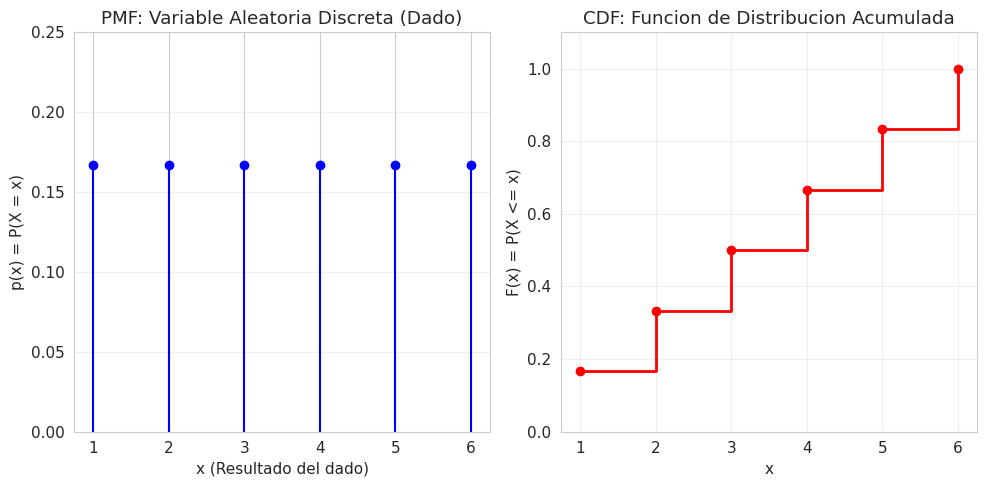

In [4]:
# Visualizacion de la PMF
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
plt.xlabel('x (Resultado del dado)')
plt.ylabel('p(x) = P(X = x)')
plt.title('PMF: Variable Aleatoria Discreta (Dado)')
plt.xticks(x_valores)
plt.ylim(0, 0.25)
plt.grid(axis='y', alpha=0.3)

# CDF
cdf_dado = np.cumsum(pmf_dado)
plt.subplot(1, 2, 2)
plt.step(x_valores, cdf_dado, where='post', color='red', linewidth=2)
plt.scatter(x_valores, cdf_dado, color='red', zorder=5)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Funcion de Distribucion Acumulada')
plt.xticks(x_valores)
plt.ylim(0, 1.1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# a) P(X = 4)
prob_4 = pmf_dado[x_valores == 4][0]
print(f"P(X = 4) = {prob_4:.4f}")

# b) P(X <= 3) usando CDF
prob_menor_3 = cdf_dado[x_valores == 3][0]
print(f"P(X <= 3) = {prob_menor_3:.4f}")

# c) P(2 <= X <= 5)
prob_entre_2_5 = cdf_dado[x_valores == 5][0] - cdf_dado[x_valores == 1][0]
print(f"P(2 <= X <= 5) = {prob_entre_2_5:.4f}")

P(X = 4) = 0.1667
P(X <= 3) = 0.5000
P(2 <= X <= 5) = 0.6667


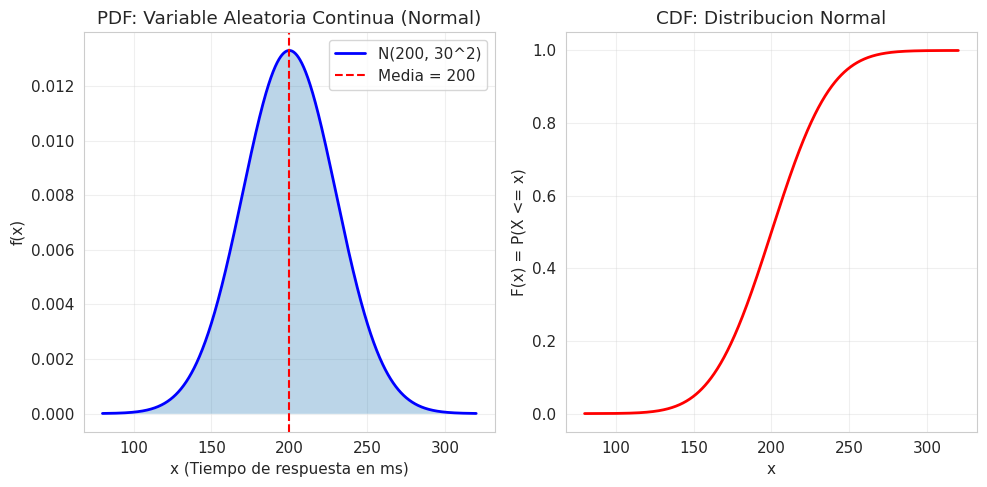

In [6]:
# Parametros de la distribucion normal
mu = 200  # media
sigma = 30  # desviacion estandar

# Crear la distribucion
dist_normal = norm(loc=mu, scale=sigma)

# Rango de valores para graficar
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# PDF
pdf_normal = dist_normal.pdf(x)

# Visualizacion
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, pdf_normal, 'b-', linewidth=2, label=f'N({mu}, {sigma}^2)')
plt.fill_between(x, pdf_normal, alpha=0.3)
plt.axvline(mu, color='red', linestyle='--', label=f'Media = {mu}')
plt.xlabel('x (Tiempo de respuesta en ms)')
plt.ylabel('f(x)')
plt.title('PDF: Variable Aleatoria Continua (Normal)')
plt.legend()
plt.grid(alpha=0.3)

# CDF
cdf_normal = dist_normal.cdf(x)
plt.subplot(1, 2, 2)
plt.plot(x, cdf_normal, 'r-', linewidth=2)
plt.xlabel('x')
plt.ylabel('F(x) = P(X <= x)')
plt.title('CDF: Distribucion Normal')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# a) P(X <= 180)
prob_menor_180 = dist_normal.cdf(180)
print(f"P(X <= 180) = {prob_menor_180:.4f} ({prob_menor_180*100:.2f}%)")

# b) P(X > 250)
prob_mayor_250 = 1 - dist_normal.cdf(250)
print(f"P(X > 250) = {prob_mayor_250:.4f} ({prob_mayor_250*100:.2f}%)")

# c) P(170 <= X <= 230)
prob_entre = dist_normal.cdf(230) - dist_normal.cdf(170)
print(f"P(170 <= X <= 230) = {prob_entre:.4f} ({prob_entre*100:.2f}%)")

# d) Percentil 95
p95 = dist_normal.ppf(0.95)
print(f"\nPercentil 95: {p95:.2f} ms")
print(f"El 95% de los tiempos de respuesta son menores a {p95:.2f} ms")

P(X <= 180) = 0.2525 (25.25%)
P(X > 250) = 0.0478 (4.78%)
P(170 <= X <= 230) = 0.6827 (68.27%)

Percentil 95: 249.35 ms
El 95% de los tiempos de respuesta son menores a 249.35 ms


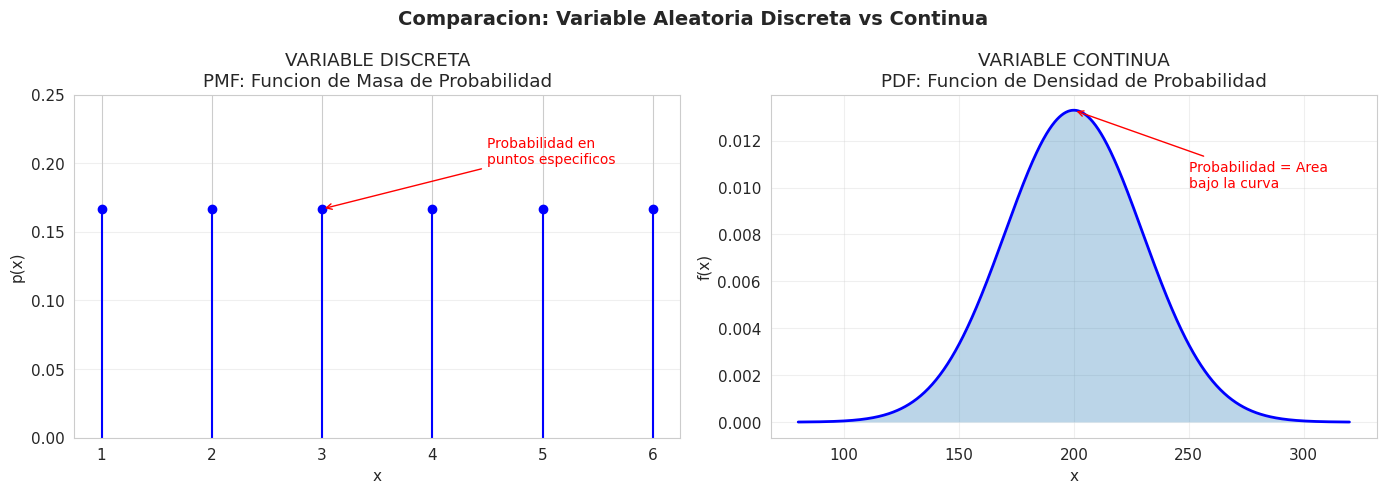

In [8]:
# Comparacion PMF vs PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Variable Discreta (Dado)
axes[0].stem(x_valores, pmf_dado, basefmt=" ", linefmt='b-', markerfmt='bo')
axes[0].set_xlabel('x')
axes[0].set_ylabel('p(x)')
axes[0].set_title('VARIABLE DISCRETA\nPMF: Funcion de Masa de Probabilidad')
axes[0].set_xticks(x_valores)
axes[0].set_ylim(0, 0.25)
axes[0].grid(axis='y', alpha=0.3)

# Anotaciones
axes[0].annotate('Probabilidad en\npuntos especificos', xy=(3, 1/6), xytext=(4.5, 0.2),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

# Variable Continua (Normal)
axes[1].plot(x, pdf_normal, 'b-', linewidth=2)
axes[1].fill_between(x, pdf_normal, alpha=0.3)
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].set_title('VARIABLE CONTINUA\nPDF: Funcion de Densidad de Probabilidad')
axes[1].grid(alpha=0.3)

# Anotaciones
axes[1].annotate('Probabilidad = Area\nbajo la curva', xy=(200, norm.pdf(200, 200, 30)), xytext=(250, 0.01),
                 arrowprops=dict(arrowstyle='->', color='red'),
                 fontsize=10, color='red')

plt.suptitle('Comparacion: Variable Aleatoria Discreta vs Continua', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Actividad grupal**
Identificar y clasificar variables aleatorias en el campus universitario.

In [17]:
# Plantilla para registro de variables
variables_unl = [
    {
        'NOMBRE': 'Número de estudiantes que ingresan a la biblioteca por hora',
        'UBICACIÓN': 'Biblioteca',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0, 1, 2, 3, ... (sin límite teórico)',
        'DISTRIBUCIÓN ESPERADA': 'Poisson'
    },
    {
        'NOMBRE': 'Tiempo de espera en la fila de la cafetería',
        'UBICACIÓN': 'Cafetería',
        'TIPO': 'Continua',
        'VALORES POSIBLES': 'X ≥ 0 (ej: 0 a 15 minutos)',
        'DISTRIBUCIÓN ESPERADA': 'Exponencial'
    },
    {
        'NOMBRE': 'Número de equipos conectados a la red Wi-Fi del    laboratorio',
        'UBICACIÓN': 'Laboratorios',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0 ≤ X ≤ 30',
        'DISTRIBUCIÓN ESPERADA': 'Binomial (n=30, p≈0.8)'
    },
    {
        'NOMBRE': 'Número de autos que ingresan al estacionamiento por día',
        'UBICACIÓN': 'Estacionamiento',
        'TIPO': 'Discreta',
        'VALORES POSIBLES': '0, 1, 2, 3, ... (sin límite teórico)',
        'DISTRIBUCIÓN ESPERADA': 'Poisson'
    },
    {
        'NOMBRE': 'Temperatura ambiente en el aula',
        'UBICACIÓN': 'Aulas de clase',
        'TIPO': 'Continua',
        'VALORES POSIBLES': '(-∞, ∞) (ej: 18°C a 30°C)',
        'DISTRIBUCIÓN ESPERADA': 'Normal'
    }
]

# Mostrar en formato de tabla
import pandas as pd
df = pd.DataFrame(variables_unl)
print(df.to_string(index=False))


                                                        NOMBRE       UBICACIÓN     TIPO                     VALORES POSIBLES  DISTRIBUCIÓN ESPERADA
   Número de estudiantes que ingresan a la biblioteca por hora      Biblioteca Discreta 0, 1, 2, 3, ... (sin límite teórico)                Poisson
                   Tiempo de espera en la fila de la cafetería       Cafetería Continua           X ≥ 0 (ej: 0 a 15 minutos)            Exponencial
Número de equipos conectados a la red Wi-Fi del    laboratorio    Laboratorios Discreta                           0 ≤ X ≤ 30 Binomial (n=30, p≈0.8)
       Número de autos que ingresan al estacionamiento por día Estacionamiento Discreta 0, 1, 2, 3, ... (sin límite teórico)                Poisson
                               Temperatura ambiente en el aula  Aulas de clase Continua            (-∞, ∞) (ej: 18°C a 30°C)                 Normal


# **Trabajo Autónomo - Kiara Condoy**
## **Distribución adicional: Binomial**
### _**Lanzar un dado 10 veces y calcular la probabilidad de obtener exactamente 3 veces el número 6.**_
### _Representación gráfica_

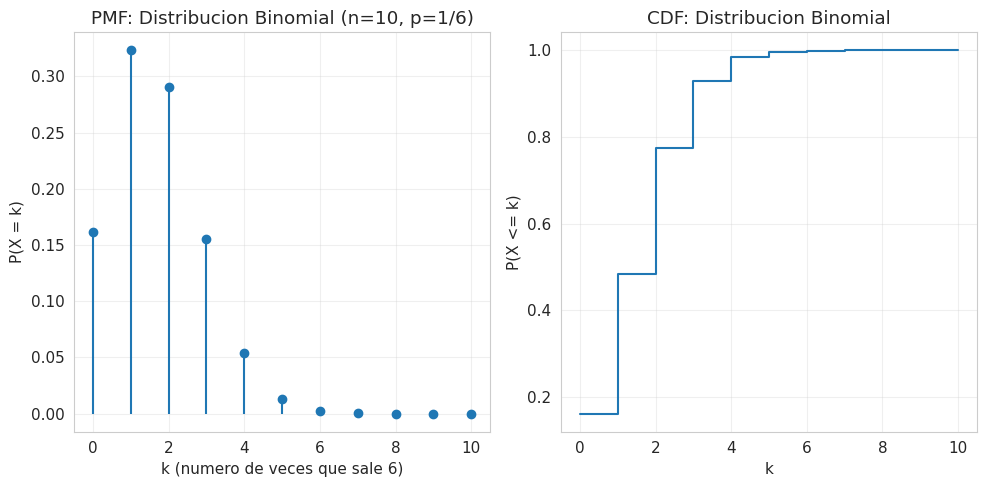

In [10]:
# Parámetros de la distribucion binomial
n = 10          # numero de lanzamientos
p = 1/6         # probabilidad de sacar 6

# Valores posibles (0 a 10 veces que puede salir 6)
x = np.arange(0, n+1)

# PMF (probabilidad exacta)
pmf_binomial = binom.pmf(x, n, p)

# CDF (probabilidad acumulada)
cdf_binomial = binom.cdf(x, n, p)

# Visualización
plt.figure(figsize=(10, 5))

# PMF
plt.subplot(1, 2, 1)
plt.stem(x, pmf_binomial, basefmt=" ")
plt.xlabel('k (numero de veces que sale 6)')
plt.ylabel('P(X = k)')
plt.title('PMF: Distribucion Binomial (n=10, p=1/6)')
plt.grid(alpha=0.3)

# CDF
plt.subplot(1, 2, 2)
plt.step(x, cdf_binomial, where='post')
plt.xlabel('k')
plt.ylabel('P(X <= k)')
plt.title('CDF: Distribucion Binomial')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### _Representación analítica_

In [14]:
# Cálculo de Probabilidades
# a) P(X = 3)
prob_3 = binom.pmf(3, n, p)
print(f"P(X = 3) = {prob_3:.4f} ({prob_3*100:.2f}%)")

# b) P(X <= 3)
prob_menor_igual_3 = binom.cdf(3, n, p)
print(f"P(X <= 3) = {prob_menor_igual_3:.4f} ({prob_menor_igual_3*100:.2f}%)")

# c) P(X > 3)
prob_mayor_3 = 1 - binom.cdf(3, n, p)
print(f"P(X > 3) = {prob_mayor_3:.4f} ({prob_mayor_3*100:.2f}%)")

# d) P(2 <= X <= 5)
prob_rango = binom.cdf(5, n, p) - binom.cdf(2-1, n, p)
print(f"P(2 <= X <= 5) = {prob_rango:.4f} ({prob_rango*100:.2f}%)")

P(X = 3) = 0.1550 (15.50%)
P(X <= 3) = 0.9303 (93.03%)
P(X > 3) = 0.0697 (6.97%)
P(2 <= X <= 5) = 0.5130 (51.30%)


## _Interpretación de resultados_
El ejercicio seleccionado, trabaja con variable:X = número de veces que sale 6 en 10 lanzamientos. El tipo de distribución es: Discreta (Binomial).

*Los parámetros que toma son:*

n=10

p=1/6

𝑘 = 3

Es decir, el dado original es uniforme discreto. Se define “éxito” como sacar 6.
Cada lanzamiento es un experimento Bernoulli. Repetir 10 veces es una distribución binomial.

**PMF:**
Calcula la probabilidad exacta de obtener k éxitos

**CDF:**
Calcula la probabilidad acumulada hasta k

*P(X=3):* probabilidad de obtener exactamente 3 veces el número 6

*P(X≤3):* probabilidad de obtener como máximo 3 veces el 6

*P(X>3):* probabilidad de obtener más de 3 veces el 6

*P(2≤X≤5):* probabilidad de obtener entre 2 y 5 veces el 6


## **Preguntas de Control**
### _**¿Cuál es la diferencia fundamental entre una variable aleatoria discreta y una continua?**_
La diferencia fundamental es que una variable aleatoria discreta toma valores contables y finitos. Sus resultados pueden enumerarse claramente, como por ejemplo el número de estudiantes o el resultado de un dado.
Una variable aleatoria continua, por otro lado, puede tomar infinitos valores dentro de un intervalo, generalmente asociados a mediciones, como el tiempo, la altura o la temperatura.
### _**¿Por qué en una variable continua P(X = x) = 0 para cualquier valor especifico x?**_
En una variable continua, los valores posibles son infinitos dentro de un intervalo. Como la probabilidad total debe ser 1, no se puede asignar una probabilidad positiva a cada punto individual. Esto se debe a que en variables continuas la probabilidad se calcula como área bajo la curva, no como valores puntuales.

### _**Explique la relación entre la PMF/PDF y la CDF. ¿Como se obtiene una de la otra?**_
La PMF y la PDF describen cómo se distribuyen las probabilidades de una variable aleatoria, mientras que la CDF muestra la probabilidad acumulada hasta un cierto valor.

En el caso de variables discretas, la PMF indica la probabilidad de cada valor específico que puede tomar la variable. A partir de estas probabilidades individuales, se construye la CDF sumando todas las probabilidades desde el valor más pequeño hasta el valor que se esté evaluando. Es decir, la CDF acumula las probabilidades de la PMF.

En el caso de variables continuas, la PDF no da probabilidades directas, sino una densidad. Para obtener la CDF, se calcula el área bajo la curva de la PDF desde el inicio hasta el valor deseado. De esta forma, la CDF representa la probabilidad acumulada hasta ese punto.

### _**Una variable aleatoria X representa el número de estudiantes que llegan tarde a clase. ¿Es X discreta o continua? Justifique.**_
Es una variable discreta, ya que representa una cantidad de estudiantes.
Además, solo puede tomar valores enteros, por lo que es una variable contable, no medible.

### _**Calcule P(X = 5) para una variable continua con PDF f(x) = 2x en [0,1]. Explique su respuesta.**_
P(X=5)=0

Esto se debe a que la función f(x)=2x está definida solo en el intervalo [0,1], por lo que 5 está fuera del dominio. Además, en cualquier variable continua:

P(X=x)=0

Por lo tanto, incluso si el valor estuviera dentro del intervalo, la probabilidad seguiría siendo 0.
### _**Dibuje aproximadamente la CDF de una variable discreta que toma valores {1, 2, 3} con probabilidades {0.3, 0.5, 0.2}.**_

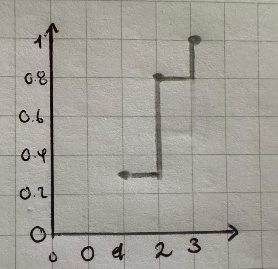

### _**Identifique una variable aleatoria continua en el contexto de la carrera de Computación y justifique porque es continua**_
Una variable aleatoria continua en el contexto de la carrera de Computación es el tiempo que tarda un servidor en responder a una solicitud de un usuario.
Se considera continua porque es una magnitud medible y no contable, ya que puede tomar valores con gran nivel de precisión (por ejemplo, en milisegundos o incluso microsegundos). A diferencia de variables discretas, no se limita a valores enteros, sino que puede asumir infinitos valores dentro de un intervalo.
Además, en el ámbito de la computación, pequeñas variaciones en el tiempo como los microsegundos, pueden ser relevantes, lo que refuerza su naturaleza continua.